# 智能食谱推荐系统：基于Qwen大模型的个性化食谱生成系统


## 项目说明

针对用户在选择食谱时面临的食材不确定、烹饪技巧不足、营养搭配困惑等问题，本项目通过以下三个步骤，为用户提供个性化的智能食谱推荐服务：

1. **用户需求识别**： 使用Qwen3-VL多模态大模型分析用户上传的食材图片或输入的食材信息
2. **智能食谱生成**： 使用Qwen3语音合成（TTS）大语言模型根据识别的食材生成个性化食谱
3. **烹饪指导输出**： 将生成的食谱内容整理为详细的烹饪步骤和营养建议

### 生成的食谱内容包括：
1. 菜品名称和简介
2. 食材列表和用量
3. 烹饪步骤和技巧
4. 营养分析和健康建议
5. 烹饪小贴士和替代方案

### 技术栈：
- OCR: PaddleOCR-VL-1.5 + OpenVINO
- VLM: Qwen3-VL-4B-Instruct + OpenVINO
- TTS: Qwen3-TTS-CustomVoice-0.6B + OpenVINO

### 内存优化：
三个模型同时加载会占用大量内存。为避免一次性加载导致内存不足，本系统采用**按需加载**策略：
- 管线运行时，仅在需要某模型时才加载
- 每个步骤完成后自动释放上一个模型的内存
- 例如：OCR 完成后释放 OCR 模型，再加载 VLM 模型

#### 目录：
- [选择推理设备](#选择推理设备)
- [模型下载与检查](#模型下载与检查)
- [生成参数设置](#生成参数设置)
- [主流程](#主流程)
- [Gradio 交互界面](#Gradio 交互界面)

## 1. 安装依赖

In [ ]:
 git clone https://github.com/z12a/OpenVINO-smart_recipe_system.git
!pip install openvino optimum[openvino] modelscope gradio Pillow torchvision psutil scipy

Defaulting to user installation because normal site-packages is not writeable


## 2. 下载模型

In [3]:
from modelscope import snapshot_download
from pathlib import Path

# 下载 VLM 模型
vlm_model_dir = Path("Qwen3-VL-4B-Instruct-int4-ov")
if not vlm_model_dir.exists():
    snapshot_download("snake7gun/Qwen3-VL-4B-Instruct-int4-ov", local_dir=str(vlm_model_dir))
    print(f"VLM 模型已下载到: {vlm_model_dir}")
else:
    print(f"VLM 模型已存在: {vlm_model_dir}")

# 下载 TTS 模型
tts_model_dir = Path("Qwen3-TTS-CustomVoice-0.6B-fp16-ov")
if not tts_model_dir.exists():
    snapshot_download("snake7gun/Qwen3-TTS-CustomVoice-0.6B-fp16-ov", local_dir=str(tts_model_dir))
    print(f"TTS 模型已下载到: {tts_model_dir}")
else:
    print(f"TTS 模型已存在: {tts_model_dir}")

# 下载 OCR 模型
ocr_model_dir = Path("PaddleOCR-VL-1.5-OpenVINO")
if not ocr_model_dir.exists():
    snapshot_download("snake7gun/PaddleOCR-VL-1.5-OpenVINO", local_dir=str(ocr_model_dir))
    print(f"OCR 模型已下载到: {ocr_model_dir}")
else:
    print(f"OCR 模型已存在: {ocr_model_dir}")

VLM 模型已存在: Qwen3-VL-4B-Instruct-int4-ov
TTS 模型已存在: Qwen3-TTS-CustomVoice-0.6B-fp16-ov
OCR 模型已存在: PaddleOCR-VL-1.5-OpenVINO


## 3. 检测系统配置

In [4]:
import psutil
import platform
import openvino as ov

print(f"操作系统: {platform.system()} {platform.release()}")
print(f"CPU: {platform.processor()}")
print(f"内存: {psutil.virtual_memory().total / 1024**3:.1f} GB")
print(f"可用内存: {psutil.virtual_memory().available / 1024**3:.1f} GB")

core = ov.Core()
print(f"OpenVINO 版本: {ov.__version__}")
print(f"可用设备: {core.available_devices}")

# 选择推理设备
device = "CPU"  # 可以改为 "GPU" 如果有
print(f"使用设备: {device}")

操作系统: Windows 11
CPU: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
内存: 15.6 GB
可用内存: 3.6 GB
OpenVINO 版本: 2026.1.0-21367-63e31528c62-releases/2026/1
可用设备: ['CPU', 'GPU']
使用设备: CPU


## 选择推理设备
[返回目录 ⬆️](#目录：)

选择用于推理的设备。CPU 兼容性最好，GPU 可在支持的硬件上提供加速。

In [5]:
from notebook_utils import device_widget

device = device_widget("CPU", exclude=["NPU"])
# 记录当前选择的字符串值，用于模型初始化
device_value = device.value
device


Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

## 4. 加载模型管理器

In [6]:


# 添加路径
# sys.path.append('modelscope-workshop/lab5/medical_pipeline')

from gradio_helper import ModelManager

# 初始化模型管理器
model_manager = ModelManager(
    ocr_model_dir="PaddleOCR-VL-1.5-OpenVINO",
    vlm_model_dir="Qwen3-VL-4B-Instruct-int4-ov",
    tts_model_dir="Qwen3-TTS-CustomVoice-0.6B-fp16-ov",
    device=device_value,
)

print("模型管理器初始化完成")


模型管理器初始化完成


## 5. 单图推理测试

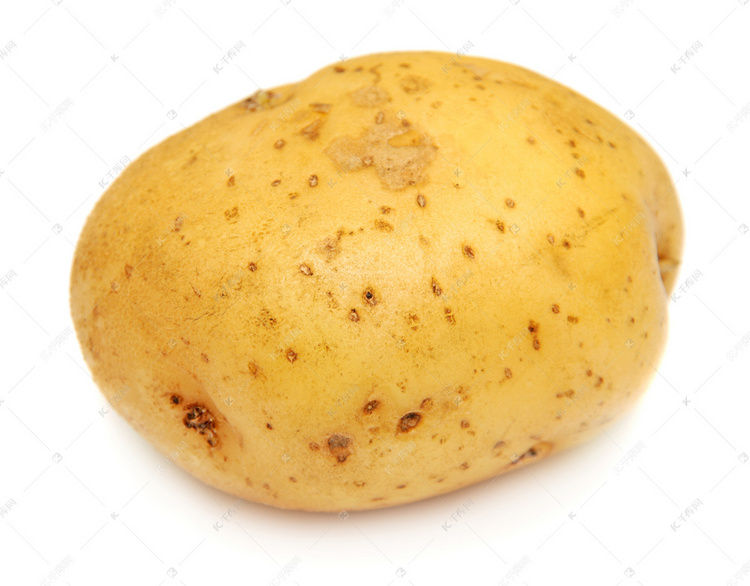

食材识别结果:
[
  {
    "name": "土豆",
    "quantity": 3,
    "brand": null,
    "category": "蔬菜",
    "production_date": null,
    "expiry_date": null,
    "expiry_status": null
  }
]
建议优先使用土豆


In [8]:
from PIL import Image
import requests
from IPython.display import display

# 下载示例图片
img_url = "https://bpic.588ku.com/back_origin_min_pic/22/08/05/e363165a50269ca55f16aa77d9abfc94.jpg!/fw/750/quality/99/unsharp/true/compress/true"
image = Image.open(requests.get(img_url, stream=True).raw)
display(image)

# 测试食材识别
from gradio_helper import vlm_extract_ingredients

vlm_model, vlm_processor = model_manager.get_vlm_model()
result, ingredients_text, tts_ready = vlm_extract_ingredients(vlm_model, vlm_processor, image=image)
print("食材识别结果:")
print(result)

# 释放模型
model_manager.release_vlm()

## 6. 食谱生成测试

In [9]:
from gradio_helper import vlm_generate_recipe

# 使用识别的食材生成食谱
vlm_model, vlm_processor = model_manager.get_vlm_model()
recipe = vlm_generate_recipe(vlm_model, vlm_processor, ingredients_text or "番茄, 鸡蛋, 洋葱")
print("生成的食谱:")
print(recipe)

# 释放模型
model_manager.release_vlm()

生成的食谱:
菜名金黄酥香烤土豆球 —— 外酥里糯，香浓不腻，营养均衡的家常美味

菜名简介
这道“金黄酥香烤土豆球”是将土豆经预处理裹粉烤制，外皮酥脆内里绵软，搭配香草与橄榄油，不加一滴油炸，健康低脂，是减脂期与健康饮食者的理想选择可作为主食配菜或轻食前菜，搭配蔬菜或蛋白质，营养均衡

—

食材清单与用量
（1人份，可按需扩展）
土豆：400克（约2个中等大小）
面粉：30克（可选，用于裹粉）
鸡蛋：1个（可选，用于打蛋液裹粉）
橄榄油：1汤匙（约15ml）
黑胡椒粉：1/4茶匙
盐：1/4茶匙
香草精或新鲜香草（如迷迭香百里香）：1/2茶匙（或1小撮）
洋葱粉或蒜粉：1/4茶匙（可选，增香）
食用油（如椰子油）：1汤匙（用于烤盘防粘）
低脂酸奶或希腊酸奶（可选）：1汤匙（用于调味，可替代蛋液）
香葱或欧芹碎：适量（装饰用）

—

详细烹饪步骤
1⃣ 土豆预处理
土豆去皮，切成约2厘米大小的圆球或小块（避免过小易碎），放入锅中加足量水，加1茶匙盐，煮至土豆变软（约15-20分钟），用筷子可轻松插入
转入冷水浸泡10分钟，防止表面变糊
用厨房纸吸干表面水分，备用

2⃣ 制作“土豆糊”（可选，提升风味）
将煮好的土豆块用叉子或刀背压成泥状，加入1/4茶匙盐1


## 7. TTS 测试

In [10]:
from gradio_helper import tts_synthesize
import numpy as np
from scipy.io.wavfile import write

# 生成语音
tts_model = model_manager.get_tts_model()
wav_data, sr = tts_synthesize(tts_model, recipe[:200], speaker="vivian", language="Chinese")
if wav_data is not None:
    write("test_audio.wav", sr, wav_data.astype(np.float32))
    print("语音已保存到 test_audio.wav")

# 释放模型
model_manager.release_tts()

SoX could not be found!

    If you do not have SoX, proceed here:
     - - - http://sox.sourceforge.net/ - - -

    If you do (or think that you should) have SoX, double-check your
    path variables.
    


✅ Patched torch.diff in masking_utils.find_packed_sequence_indices for OpenVINO compatibility

********
********
 
No checkpoint_path.txt found, trying to load processor from model_dir
Loading OpenVINO speech tokenizer
语音已保存到 test_audio.wav


## 8. 完整管线测试

In [6]:
from gradio_helper import recipe_recommender_pipeline
from scipy.io.wavfile import write
import numpy as np

# 测试完整管线
result = recipe_recommender_pipeline(
    model_manager=model_manager,
    image_path=None,
    input_text="番茄, 鸡蛋, 洋葱, 大蒜",
    input_type="text",
    enable_split=False,
    tts_speaker="vivian",
    tts_language="Chinese",
)

print("食材:", result.get("ingredients"))
print("食谱:", result.get("recipe"))
if result.get("audio"):
    sr, wav_data = result["audio"]
    write("recipe_audio.wav", sr, wav_data.astype(np.float32))
    print("语音食谱已保存到 recipe_audio.wav")

No checkpoint_path.txt found, trying to load processor from model_dir
Loading OpenVINO speech tokenizer
食材: 番茄, 鸡蛋, 洋葱, 大蒜
食谱: 菜名
“金黄番茄蛋花鲜香意”
—— 一道色泽诱人鲜香浓郁营养均衡的家常开胃菜，融合番茄的酸甜鸡蛋的柔滑与洋葱大蒜的辛香，适合搭配米饭或作为轻食主菜

—

食材清单与用量
番茄：300克（中等大小，约4-5个）
鸡蛋：2个（约50克）
洋葱：1/4个（约40克）
大蒜：2瓣（约10克）
食用油：1汤匙（约15毫升）
盐：1/2茶匙（约2.5克）
白胡椒粉：1/4茶匙（约0.5克）
糖：1茶匙（约5克，可选，用于平衡酸味）
清水或高汤：50毫升（可选，用于调稀汤汁）
香油（可选）：几滴（提升香气）

—

详细烹饪步骤

Step 1：预处理食材
番茄洗净，去蒂，切成小块（约1cm见方）
洋葱切细丝，大蒜剁成蒜末
鸡蛋打入碗中，加少许盐（约1/4茶匙）打散备用

Step 2：炒香底料
锅中放1汤匙油，中火加热，放入蒜末爆香（约15秒），再加入洋葱丝炒至透明微黄（约1分钟），香气四溢
加入番茄块，翻炒约2分钟，炒至番茄变软出汁

Step 3：调味与勾芡
加入1茶匙糖（可选，中和酸味）1/2茶匙盐1/4茶匙白胡椒粉，搅拌均匀
加入50毫升清水或高汤，搅拌至汤汁略浓稠（约3分钟）
用勺子或锅铲将汤汁搅匀，防止糊底

Step 4：滑蛋入锅
语音食谱已保存到 recipe_audio.wav


## 9. 启动 Gradio 交互界面

In [7]:
from gradio_helper import make_demo

# 创建 Gradio 界面
demo = make_demo(model_manager)

# 启动界面
demo.launch(server_name="0.0.0.0", server_port=7860)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.
